# Interacting Qubits

Welcome to the first part of this tutorial at Euroscipy 2026.
In this notebook we will show how to visualize a qubit state and how to simulate the dynamics of interacting qubits with and without an environment.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import qutip as qt

# Visualizing a Qubit

In [2]:
def bloch_state(theta, phi):
    """
    Return a single-qubit state |psi> on the Bloch sphere.
    theta, phi in radians.
    """
    return np.cos(theta / 2) * qt.basis(2, 0) + np.exp(1j * phi) * np.sin(
        theta / 2
    ) * qt.basis(2, 1)


def plot_on_bloch(states, labels=None):
    """
    Plot one or more states on the Bloch sphere.

    states: list of Qobj kets or a single Qobj.
    labels: optional list of labels.
    """
    if isinstance(states, qt.Qobj):
        states = [states]
    b = qt.Bloch()
    for i, s in enumerate(states):
        b.add_states(s)
        if labels is not None:
            b.add_annotation(s, labels[i])
    b.show()

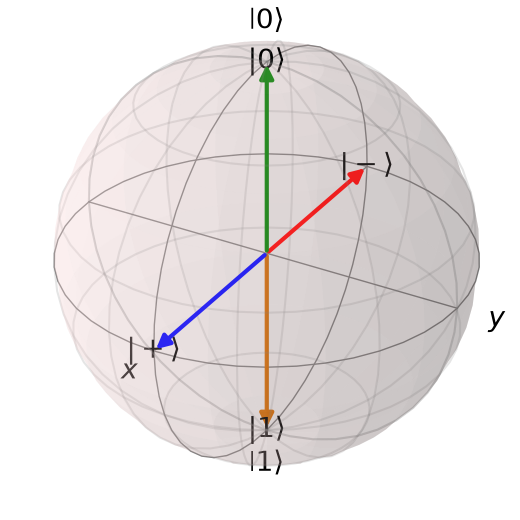

In [3]:
# Example: |0>, |1>, |+>, |-> on the Bloch sphere
zero = qt.basis(2, 0)
one = qt.basis(2, 1)
plus = (zero + one) / np.sqrt(2)
minus = (zero - one) / np.sqrt(2)

plot_on_bloch(
    [zero, one, plus, minus],
    labels=[r"$|0\rangle$", r"$|1\rangle$", r"$|+\rangle$", r"$|-\rangle$"],
)

# Two Interacting Qubits

In [4]:
# Building the Hamiltonian
epsilonA = 0.5
epsilonB = 0.5
g = 0.2

szA = qt.sigmaz() & qt.qeye(2)  # sigma_z
szB = qt.qeye(2) & qt.sigmaz()
sxA = qt.sigmax() & qt.qeye(2)  # sigma_x
sxB = qt.qeye(2) & qt.sigmax()

spA = qt.sigmap() & qt.qeye(2)  # sigma_+
spB = qt.qeye(2) & qt.sigmap()
smA = qt.sigmam() & qt.qeye(2)  # sigma_-
smB = qt.qeye(2) & qt.sigmam()

H = epsilonA * szA + epsilonB * szB + g * (spA * smB + smA * spB)

print(H)

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 1.   0.   0.   0. ]
 [ 0.   0.   0.2  0. ]
 [ 0.   0.2  0.   0. ]
 [ 0.   0.   0.  -1. ]]


In [5]:
psi0 = qt.basis(2, 0) & qt.basis(2, 1)  # initial state
tlist = np.linspace(0, 40, 100)  # simulation time

In [6]:
se_result = qt.sesolve(H, psi0, tlist, e_ops=[szA, szB])

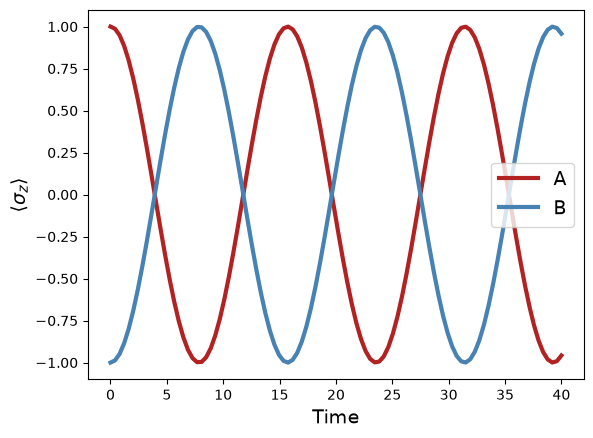

In [7]:
lw = 3
fs = 14
plt.plot(tlist, se_result.expect[0], label="A", c="firebrick", linewidth=lw)
plt.plot(tlist, se_result.expect[1], label="B", c="steelblue", linewidth=lw)
plt.xlabel("Time", fontsize=fs)
plt.ylabel(r"$\langle \sigma_z \rangle$", fontsize=fs)
plt.legend(fontsize=fs)
plt.show()

# Two Qubits and an Environment

In [8]:
# dissipation rate
gA = np.sqrt(4e-2)
gB = np.sqrt(4e-2)

c_ops = [gA * smA, gB * smB]

In [9]:
me_result = qt.mesolve(H, psi0, tlist, c_ops, e_ops=[szA, szB])

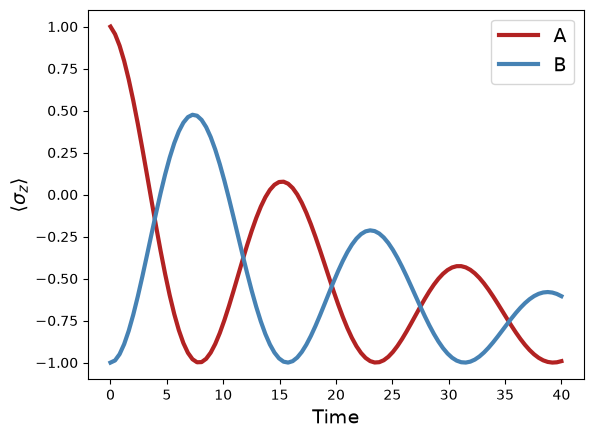

In [10]:
plt.plot(tlist, me_result.expect[0], label="A", c="firebrick", linewidth=lw)
plt.plot(tlist, me_result.expect[1], label="B", c="steelblue", linewidth=lw)
plt.xlabel("Time", fontsize=fs)
plt.ylabel(r"$\langle \sigma_z \rangle$", fontsize=fs)
plt.legend(fontsize=fs)
plt.show()

In [11]:
qt.about()


QuTiP: Quantum Toolbox in Python
Copyright (c) QuTiP team 2011 and later.
Current admin team: Alexander Pitchford, Nathan Shammah, Shahnawaz Ahmed, Neill Lambert, Eric Giguère, Boxi Li, Simon Cross, Asier Galicia, Paul Menczel, and Patrick Hopf.
Board members: Daniel Burgarth, Robert Johansson, Anton F. Kockum, Franco Nori and Will Zeng.
Original developers: R. J. Johansson & P. D. Nation.
Previous lead developers: Chris Granade & A. Grimsmo.
Currently developed through wide collaboration. See https://github.com/qutip for details.

QuTiP Version:      5.3.0
Numpy Version:      2.5.1
Scipy Version:      1.18.0
Cython Version:     3.2.8
Matplotlib Version: 3.11.1
Python Version:     3.12.0
Number of CPUs:     4
BLAS Info:          blas
INTEL MKL Ext:      None
Platform Info:      Linux (x86_64)
Installation path:  /home/runner/miniconda3/envs/test-environment-v5/lib/python3.12/site-packages/qutip

Installed QuTiP family packages
-------------------------------



qutip-qoc: 0.3.0.dev0+1c18818
qutip-jax: 0.1.1.dev8
qutip-qtrl: 0.2.1.dev0+2a34540
qutip-qip: 0.4.2

Please cite QuTiP in your publication.
For your convenience a bibtex reference can be easily generated using `qutip.cite()`
